# Spatial Filtering Experiments

**Filters:** Gaussian Low-Pass (denoise) and Unsharp Masking (sharpen).

**Method:** corrupted images are preprocessed (resize 224 + minmax), then each
filter's parameters are swept and scored against the **ground-truth** image with
**PSNR** and **SSIM**. The best parameters per filter are chosen by *average rank*
(rank by PSNR + rank by SSIM, lowest wins) and applied to all 2500 images.

Run `python -m filtering_spatial.optimize_spatial` first to generate the outputs
and report files this notebook reads. This notebook only visualises results.

In [1]:
import sys, json
sys.path.insert(0, '..')
from pathlib import Path

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

PROJECT_ROOT = Path('..').resolve()
SPATIAL  = PROJECT_ROOT / 'output' / '02_spatial_filtering'
NORM     = PROJECT_ROOT / 'output' / '01_preprocessing' / 'normalized'
GT       = PROJECT_ROOT / 'output' / '01_preprocessing' / 'groundtruth_normalized'
FIG      = SPATIAL / 'figures'; FIG.mkdir(parents=True, exist_ok=True)

assert (SPATIAL / 'best_params.json').exists(), \
    'Run: python -m filtering_spatial.optimize_spatial'

best   = json.loads((SPATIAL / 'best_params.json').read_text())
g_sweep = pd.read_csv(SPATIAL / 'gaussian_sweep.csv')
u_sweep = pd.read_csv(SPATIAL / 'unsharp_sweep.csv')
g_m = pd.read_csv(SPATIAL / 'gaussian_best_metrics.csv').set_index('image_name')
u_m = pd.read_csv(SPATIAL / 'unsharp_best_metrics.csv').set_index('image_name')
labels = pd.read_csv(PROJECT_ROOT / 'data' / 'balanced_2500.csv').set_index('Image Index')['Finding Labels']

def load(d, name):
    return cv2.imread(str(d / name), cv2.IMREAD_GRAYSCALE)

best

{'sweep_size': 200,
 'preprocess': {'size': 224, 'norm': 'minmax'},
 'selection': 'average rank of PSNR and SSIM (lower is better)',
 'gaussian': {'params': {'kernel_size': 7, 'sigma': 1.0},
  'sweep_psnr': 25.431223645893457,
  'sweep_ssim': 0.860916072085741,
  'fullset_psnr': 25.39909987261643,
  'fullset_ssim': 0.8580612181093685,
  'output_dir': 'output/02_spatial_filtering/gaussian'},
 'unsharp': {'params': {'radius': 0.5, 'amount': 1.5, 'threshold': 10},
  'sweep_psnr': 25.43398733459727,
  'sweep_ssim': 0.7871618991982845,
  'fullset_psnr': 25.38194152381124,
  'fullset_ssim': 0.7869949259669509,
  'output_dir': 'output/02_spatial_filtering/unsharp'}}

## 1. Best parameters and full-set scores

In [2]:
summary = pd.DataFrame([
    {'filter': 'Gaussian LPF', **best['gaussian']['params'],
     'mean_PSNR': best['gaussian']['fullset_psnr'], 'mean_SSIM': best['gaussian']['fullset_ssim']},
    {'filter': 'Unsharp Masking', **best['unsharp']['params'],
     'mean_PSNR': best['unsharp']['fullset_psnr'], 'mean_SSIM': best['unsharp']['fullset_ssim']},
])
summary.round(4)

,filter,kernel_size,sigma,mean_PSNR,mean_SSIM,radius,amount,threshold
0,Gaussian LPF,7.0,1.0,25.3991,0.8581,NaN,NaN,NaN
1,Unsharp Masking,NaN,NaN,25.3819,0.7870,0.5,1.5,10.0


## 2. Qualitative comparison
Ground truth vs corrupted input vs each filter's best result (PSNR/SSIM vs ground truth).

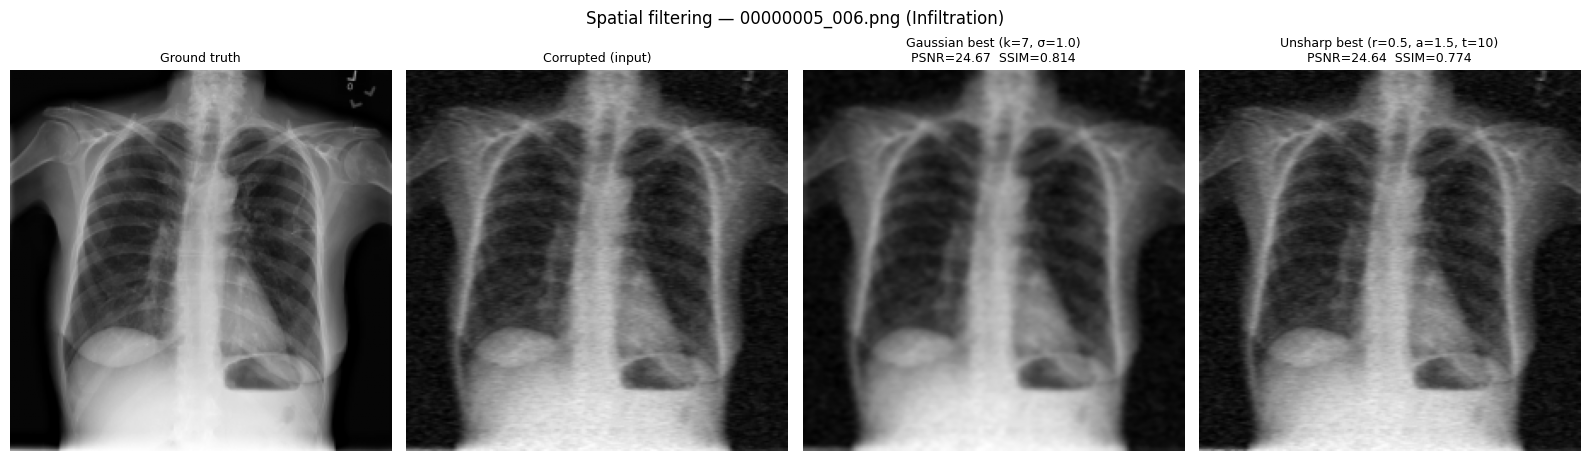

In [3]:
name = sorted(p.name for p in (SPATIAL / 'gaussian').glob('*.png'))[0]
gp, up = best['gaussian']['params'], best['unsharp']['params']
panels = [
    ('Ground truth', load(GT, name), None),
    ('Corrupted (input)', load(NORM, name), None),
    (f"Gaussian best (k={gp['kernel_size']}, \u03c3={gp['sigma']})", load(SPATIAL / 'gaussian', name), g_m.loc[name]),
    (f"Unsharp best (r={up['radius']}, a={up['amount']}, t={up['threshold']})", load(SPATIAL / 'unsharp', name), u_m.loc[name]),
]
fig, axes = plt.subplots(1, 4, figsize=(16, 4.5))
for ax, (title, img, m) in zip(axes, panels):
    ax.imshow(img, cmap='gray')
    if m is not None:
        title += f'\nPSNR={m.psnr:.2f}  SSIM={m.ssim:.3f}'
    ax.set_title(title, fontsize=9); ax.axis('off')
plt.suptitle(f'Spatial filtering \u2014 {name} ({labels.get(name, "?")})', fontsize=12, y=1.02)
plt.tight_layout()
plt.savefig(FIG / 'qualitative_comparison.png', dpi=130, bbox_inches='tight')
plt.show()

## 3. Visual parameter grids (single sample)
Qualitative look at how each parameter changes the image.

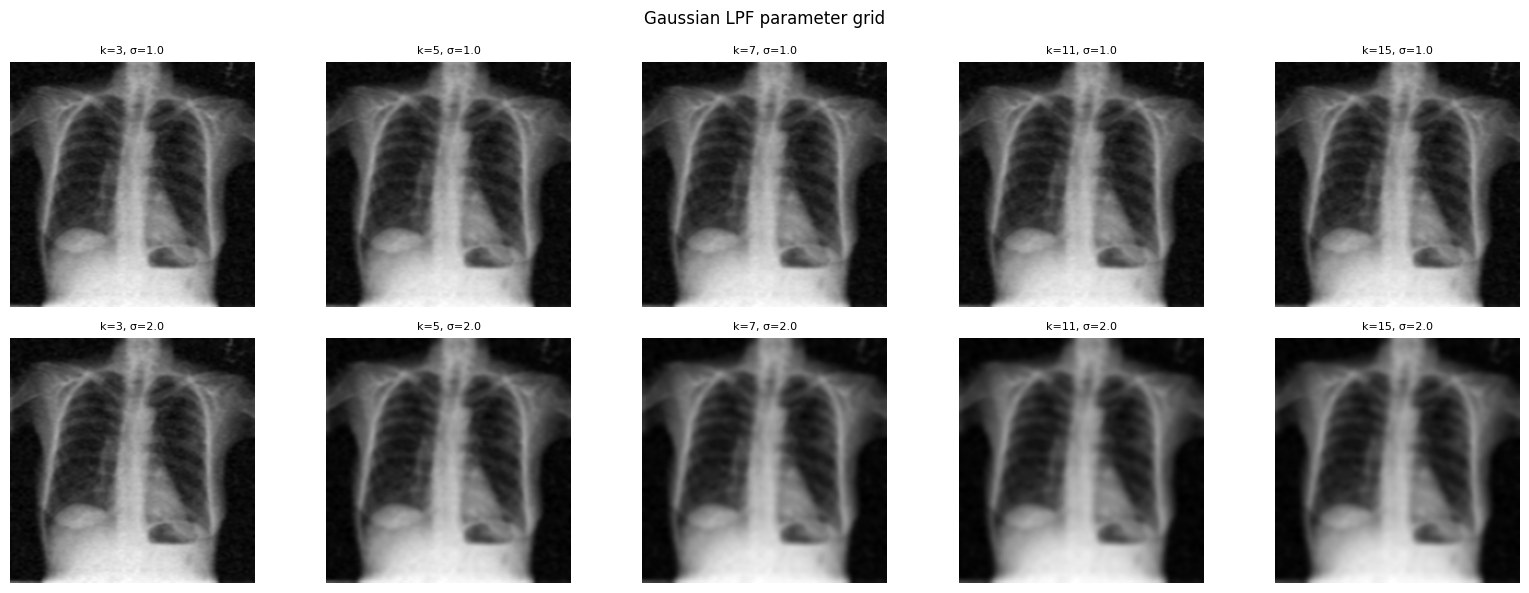

In [4]:
from filtering_spatial.gaussian_lpf import GaussianLPF
from filtering_spatial.unsharp_masking import UnsharpMasking
sample = load(NORM, name)
glpf, um = GaussianLPF(), UnsharpMasking()

kernel_sizes, sigmas = [3, 5, 7, 11, 15], [1.0, 2.0]
fig, axes = plt.subplots(len(sigmas), len(kernel_sizes), figsize=(16, 6))
for r, sig in enumerate(sigmas):
    for c, k in enumerate(kernel_sizes):
        axes[r, c].imshow(glpf.apply_with_params(sample, k, sig), cmap='gray')
        axes[r, c].set_title(f'k={k}, \u03c3={sig}', fontsize=8); axes[r, c].axis('off')
plt.suptitle('Gaussian LPF parameter grid', fontsize=12); plt.tight_layout()
plt.savefig(FIG / 'gaussian_param_grid.png', dpi=130); plt.show()

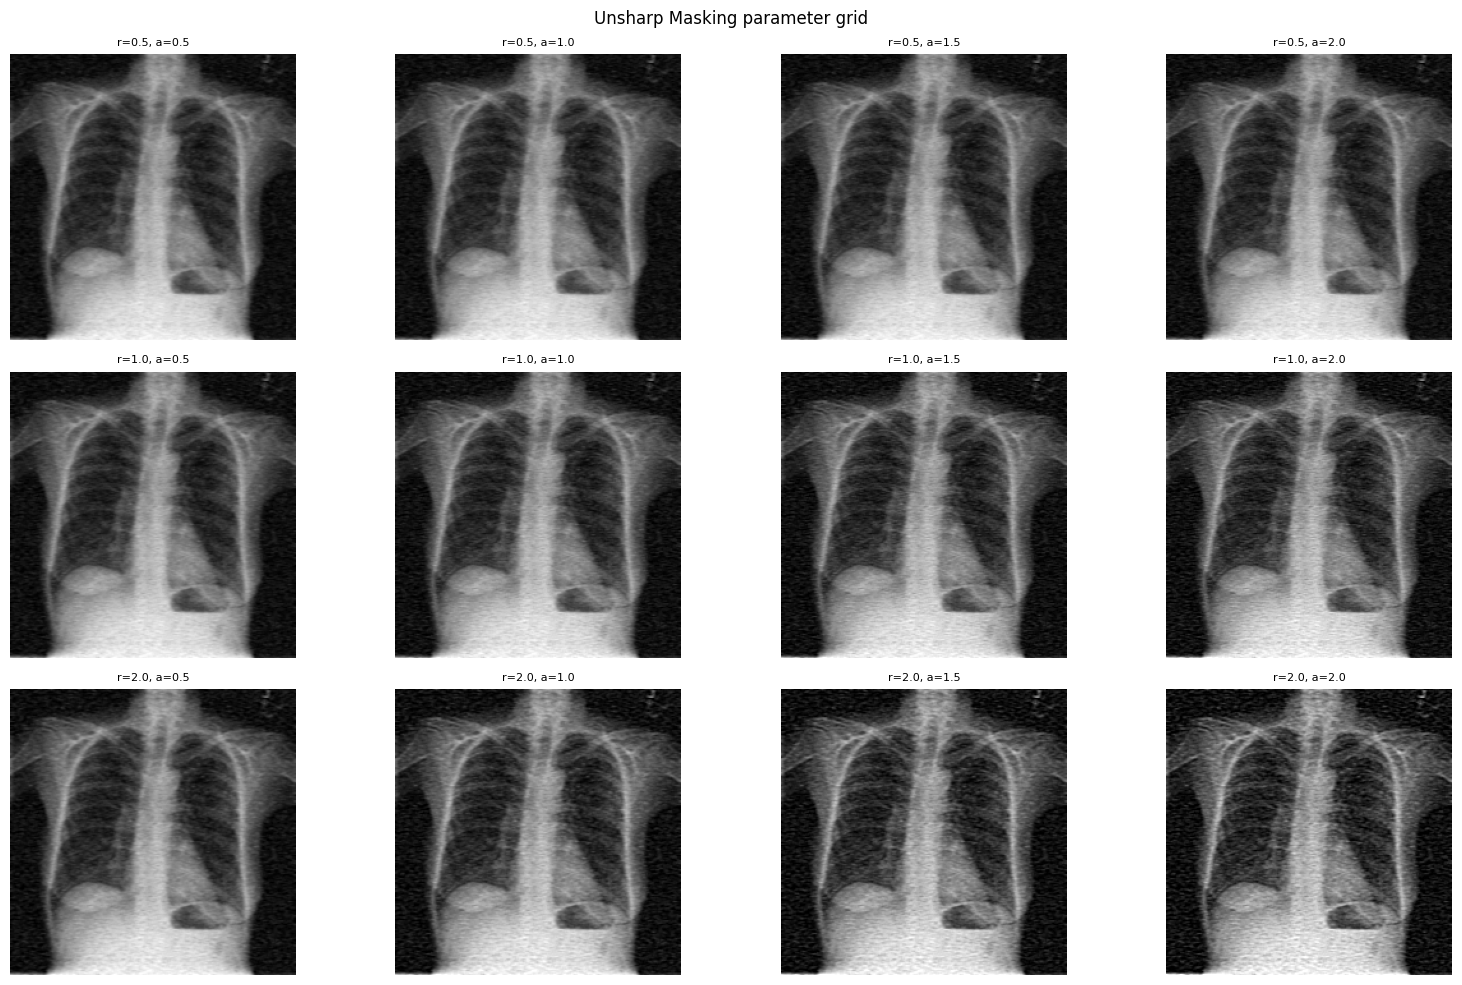

In [5]:
radii, amounts = [0.5, 1.0, 2.0], [0.5, 1.0, 1.5, 2.0]
fig, axes = plt.subplots(len(radii), len(amounts), figsize=(16, 10))
for r, rad in enumerate(radii):
    for c, a in enumerate(amounts):
        axes[r, c].imshow(um.apply_with_params(sample, rad, a, 0), cmap='gray')
        axes[r, c].set_title(f'r={rad}, a={a}', fontsize=8); axes[r, c].axis('off')
plt.suptitle('Unsharp Masking parameter grid', fontsize=12); plt.tight_layout()
plt.savefig(FIG / 'unsharp_param_grid.png', dpi=130); plt.show()

## 4. PSNR / SSIM vs parameters (quantitative)
Scores averaged over the sweep subset. Red circle = chosen best.

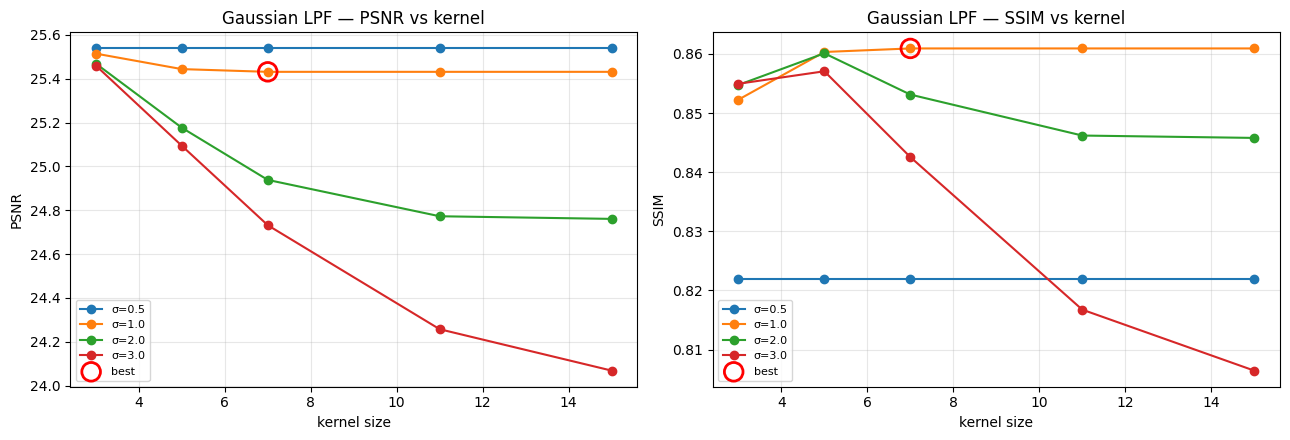

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
for metric, ax in zip(['psnr', 'ssim'], axes):
    for sigma, sub in g_sweep.groupby('sigma'):
        sub = sub.sort_values('kernel_size')
        ax.plot(sub.kernel_size, sub[metric], marker='o', label=f'\u03c3={sigma}')
    bp = best['gaussian']['params']
    by = g_sweep[(g_sweep.kernel_size == bp['kernel_size']) & (g_sweep.sigma == bp['sigma'])][metric].iloc[0]
    ax.scatter([bp['kernel_size']], [by], s=180, facecolors='none', edgecolors='red', linewidths=2, zorder=5, label='best')
    ax.set_xlabel('kernel size'); ax.set_ylabel(metric.upper())
    ax.set_title(f'Gaussian LPF \u2014 {metric.upper()} vs kernel'); ax.legend(fontsize=8); ax.grid(alpha=0.3)
plt.tight_layout(); plt.savefig(FIG / 'gaussian_sweep_curves.png', dpi=130, bbox_inches='tight'); plt.show()

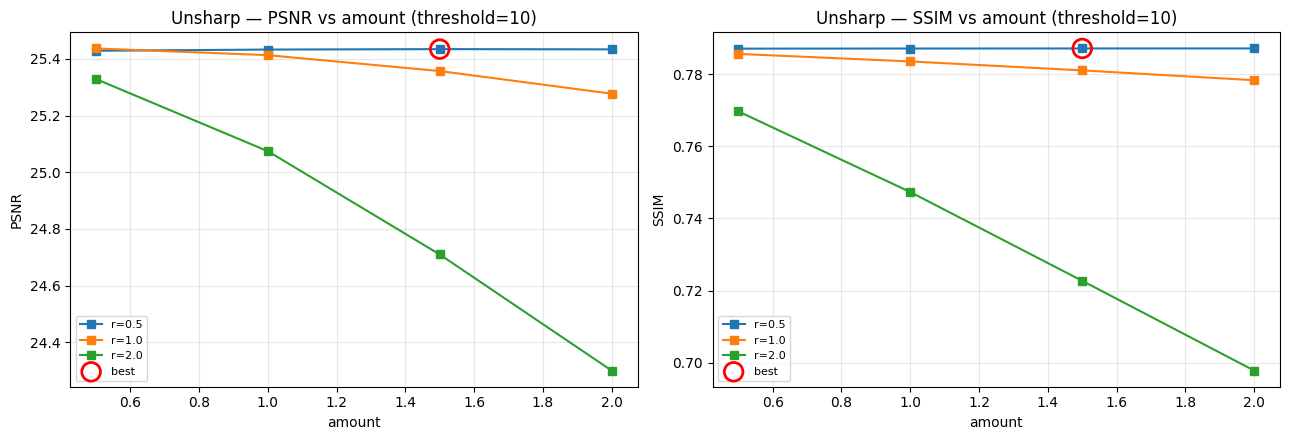

In [7]:
best_t = best['unsharp']['params']['threshold']
u_t = u_sweep[u_sweep.threshold == best_t]
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
for metric, ax in zip(['psnr', 'ssim'], axes):
    for radius, sub in u_t.groupby('radius'):
        sub = sub.sort_values('amount')
        ax.plot(sub.amount, sub[metric], marker='s', label=f'r={radius}')
    bp = best['unsharp']['params']
    by = u_sweep[(u_sweep.radius == bp['radius']) & (u_sweep.amount == bp['amount']) & (u_sweep.threshold == bp['threshold'])][metric].iloc[0]
    ax.scatter([bp['amount']], [by], s=180, facecolors='none', edgecolors='red', linewidths=2, zorder=5, label='best')
    ax.set_xlabel('amount'); ax.set_ylabel(metric.upper())
    ax.set_title(f'Unsharp \u2014 {metric.upper()} vs amount (threshold={best_t})'); ax.legend(fontsize=8); ax.grid(alpha=0.3)
plt.tight_layout(); plt.savefig(FIG / 'unsharp_sweep_curves.png', dpi=130, bbox_inches='tight'); plt.show()

## 5. Metric distribution over all 2500 images
Per-image PSNR/SSIM of each filter's best result. Dashed line = mean.

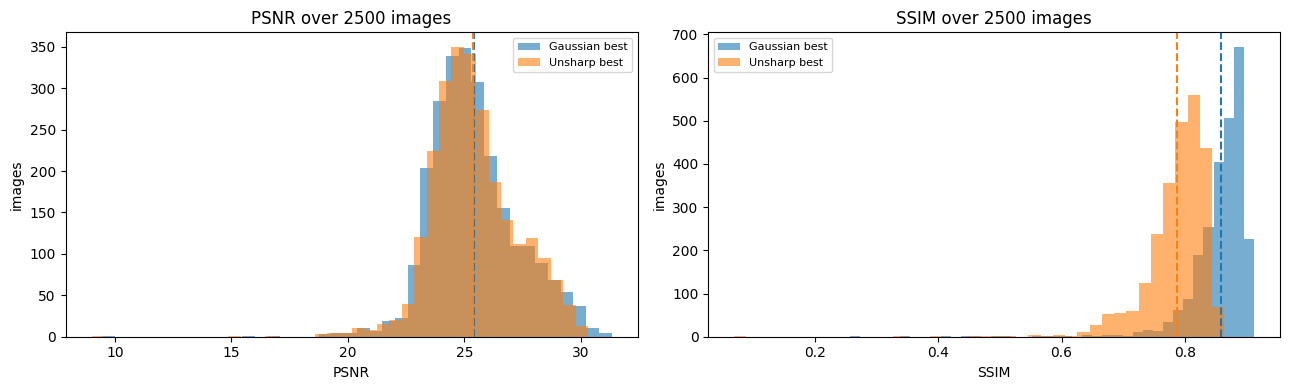

Gaussian: PSNR=25.40+/-1.88  SSIM=0.8581+/-0.0456
Unsharp : PSNR=25.38+/-1.82  SSIM=0.7870+/-0.0500


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for metric, ax in zip(['psnr', 'ssim'], axes):
    ax.hist(g_m[metric], bins=40, alpha=0.6, label='Gaussian best')
    ax.hist(u_m[metric], bins=40, alpha=0.6, label='Unsharp best')
    ax.axvline(g_m[metric].mean(), color='C0', ls='--')
    ax.axvline(u_m[metric].mean(), color='C1', ls='--')
    ax.set_xlabel(metric.upper()); ax.set_ylabel('images')
    ax.set_title(f'{metric.upper()} over 2500 images'); ax.legend(fontsize=8)
plt.tight_layout(); plt.savefig(FIG / 'metric_distributions.png', dpi=130, bbox_inches='tight'); plt.show()

print(f"Gaussian: PSNR={g_m.psnr.mean():.2f}+/-{g_m.psnr.std():.2f}  SSIM={g_m.ssim.mean():.4f}+/-{g_m.ssim.std():.4f}")
print(f"Unsharp : PSNR={u_m.psnr.mean():.2f}+/-{u_m.psnr.std():.2f}  SSIM={u_m.ssim.mean():.4f}+/-{u_m.ssim.std():.4f}")